(2060, 16)
transaction_id          object
client_id               object
date_transaction        object
montant                 object
devise                  object
taux_change_eur        float64
montant_eur            float64
categorie               object
produit                 object
agence                  object
type_operation          object
statut                  object
score_credit_client    float64
segment_client          object
solde_avant             object
taux_interet           float64
dtype: object
  transaction_id client_id     date_transaction  montant devise  \
0      TXN000559   CLI0060  2022-04-19 02:31:00  2050.42    EUR   
1      TXN001154   CLI0057  2024-06-20 20:51:00  -123.66    GBP   
2      TXN000764   CLI0015  2024-08-28 05:03:00  -396.17    EUR   
3      TXN001598   CLI0045  2024-01-07 08:16:00    225.2    EUR   
4      TXN001873   CLI0034  2024-08-11 19:52:00   935.32    EUR   

   taux_change_eur  montant_eur      categorie              produit  \
0    

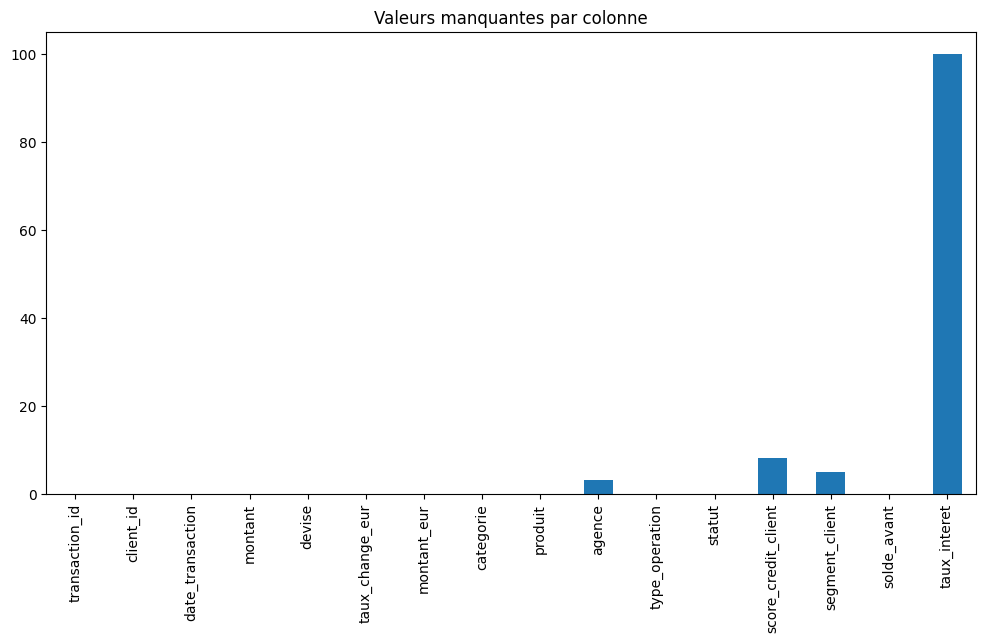

60
2022-01-01 02:50:00 2024-12-31 14:06:00


In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Lire le fichier
df = pd.read_csv("bankdata.csv")

# Inspecter la structure
print(df.shape)
print(df.dtypes)
print(df.head())
print(df.describe(include='all'))

# Taux de valeurs manquantes
missing_ratio = df.isna().mean() * 100
print(missing_ratio)

# Visualisation des valeurs manquantes
plt.figure(figsize=(12,6))
missing_ratio.plot(kind='bar')
plt.title("Valeurs manquantes par colonne")
plt.show()

# Vérification des doublons
print(df.duplicated(subset='transaction_id').sum())

# Analyser les écarts de date
df['date_transaction'] = pd.to_datetime(df['date_transaction'], errors='coerce')
print(df['date_transaction'].min(), df['date_transaction'].max())


2️⃣ Nettoyage des données

In [11]:
# 1. Supprimer doublons (conserver la première occurrence)
df = df.drop_duplicates(subset='transaction_id', keep='first')

# Retirer espaces et remplacer virgules
df['montant'] = df['montant'].astype(str).str.replace(',', '.').str.strip()

# Convertir en float et remplacer les erreurs par NaN
df['montant'] = pd.to_numeric(df['montant'], errors='coerce')

# 2. Corriger les dates
df['date_transaction'] = pd.to_datetime(df['date_transaction'], format='%Y-%m-%d %H:%M:%S', errors='coerce')

# 3. Corriger montants
df['montant'] = df['montant'].astype(str).str.replace(',', '.').astype(float)

# 4. Nettoyer solde_avant
df['solde_avant'] = df['solde_avant'].str.replace(' EUR','', regex=False).str.replace(',','.', regex=False).astype(float)

# 5. Normaliser les devises
df['devise'] = df['devise'].str.upper()

# 6. Harmoniser segment_client
df['segment_client'] = df['segment_client'].str.title()

# 7. Supprimer espaces parasites dans agence
df['agence'] = df['agence'].str.strip()

# 8. Imputation des valeurs manquantes
for col in ['taux_change_eur', 'montant_eur', 'score_credit_client']:
    df[col] = df[col].fillna(df[col].median())

for col in ['categorie', 'produit', 'statut', 'type_operation', 'segment_client']:
    df[col] = df[col].fillna(df[col].mode()[0])

3️⃣ Détection & Traitement des Valeurs Aberrante

In [12]:
from scipy import stats

# Détection IQR pour montant
Q1 = df['montant'].quantile(0.25)
Q3 = df['montant'].quantile(0.75)
IQR = Q3 - Q1
df['anomaly_montant'] = ((df['montant'] < Q1 - 1.5*IQR) | (df['montant'] > Q3 + 1.5*IQR))

# Détection pour score_credit_client
Q1_score = df['score_credit_client'].quantile(0.25)
Q3_score = df['score_credit_client'].quantile(0.75)
IQR_score = Q3_score - Q1_score
df['anomaly_score'] = ((df['score_credit_client'] < 0) | (df['score_credit_client'] > 850))

# Flag général
df['is_anomaly'] = df['anomaly_montant'] | df['anomaly_score']

# Z-score pour montant
mean_montant = df['montant'].mean()
std_montant = df['montant'].std()
df['zscore_montant'] = (df['montant'] - mean_montant) / std_montant
df['anomaly_montant_z'] = df['zscore_montant'].abs() > 3  # seuil 3 sigma

# Z-score pour score_credit_client
mean_score = df['score_credit_client'].mean()
std_score = df['score_credit_client'].std()
df['zscore_score'] = (df['score_credit_client'] - mean_score) / std_score
df['anomaly_score_z'] = df['zscore_score'].abs() > 3

# Flag général combinant IQR + Z-score
df['is_anomaly'] = df['anomaly_montant'] | df['anomaly_score'] | df['anomaly_montant_z'] | df['anomaly_score_z']

4️⃣ Feature Engineering 

In [13]:
# Extraire date
df['annee'] = df['date_transaction'].dt.year
df['mois'] = df['date_transaction'].dt.month
df['trimestre'] = df['date_transaction'].dt.quarter
df['jour_semaine'] = df['date_transaction'].dt.day_name()

# Vérifier montant_eur
df['montant_eur_verifie'] = df['montant'] / df['taux_change_eur']
df['montant_eur_diff'] = df['montant_eur'] - df['montant_eur_verifie']

# Categorie risque
df['categorie_risque'] = pd.cut(df['score_credit_client'],
                                bins=[-np.inf, 579, 699, np.inf],
                                labels=['High','Medium','Low'])

# Solde net par client
solde = df.groupby('client_id').apply(lambda x: (x.loc[x['type_operation']=='Credit','montant'].sum() - 
                                                x.loc[x['type_operation']=='Debit','montant'].sum()))
df_solde = solde.reset_index(name='solde_net')
df = df.merge(df_solde, on='client_id', how='left')

# Agrégation par client
client_agg = df.groupby('client_id').agg(
    nb_transactions=('transaction_id','count'),
    montant_moyen=('montant','mean'),
    nb_produits_distincts=('produit','nunique')
).reset_index()
df = df.merge(client_agg, on='client_id', how='left')

# Taux de rejet par agence
taux_rejet = df.groupby('agence').apply(lambda x: (x['statut']=='Rejete').mean()).reset_index(name='taux_rejet')
df = df.merge(taux_rejet, on='agence', how='left')
print(taux_rejet)

C:\Users\hp\AppData\Local\Temp\ipykernel_2780\112304516.py:17: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  solde = df.groupby('client_id').apply(lambda x: (x.loc[x['type_operation']=='Credit','montant'].sum() -
C:\Users\hp\AppData\Local\Temp\ipykernel_2780\112304516.py:31: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  taux_rejet = df.groupby('agence').apply(lambda x: (x['statut']=='Rejete').mean()).reset_index(name

                 agence  taux_rejet
0    Bordeaux-Meriadeck    0.045198
1     Lille-Grand-Place    0.042056
2        Lyon-Part-Dieu    0.040134
3  Marseille-Vieux-Port    0.055728
4       Nantes-Commerce    0.085000
5          Nice-Massena    0.076336
6          Paris-Centre    0.065789
7     Toulouse-Capitole    0.068063
